In [47]:
import pandas as pd 

In [48]:
import numpy as np

In [49]:
from sklearn.model_selection import train_test_split

In [50]:
from sklearn.linear_model import LinearRegression

In [51]:
from sklearn.metrics import mean_squared_error, r2_score

In [52]:
data= pd.read_csv("sentiment.csv")

In [53]:
data.head()

,Unnamed: 0.1,Unnamed: 0,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour
0,0,0,Enjoying a beautiful day at the park! ...,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15.0,30.0,USA,2023,1,15,12
1,1,1,Traffic was terrible this morning. ...,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5.0,10.0,Canada,2023,1,15,8
2,2,2,Just finished an amazing workout! 💪 ...,Positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20.0,40.0,USA,2023,1,15,15
3,3,3,Excited about the upcoming weekend getaway! ...,Positive,2023-01-15 18:20:00,AdventureX,Facebook,#Travel #Adventure,8.0,15.0,UK,2023,1,15,18
4,4,4,Trying out a new recipe for dinner tonight. ...,Neutral,2023-01-15 19:55:00,ChefCook,Instagram,#Cooking #Food,12.0,25.0,Australia,2023,1,15,19


In [54]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0.1  732 non-null    int64  
 1   Unnamed: 0    732 non-null    int64  
 2   Text          732 non-null    str    
 3   Sentiment     732 non-null    str    
 4   Timestamp     732 non-null    str    
 5   User          732 non-null    str    
 6   Platform      732 non-null    str    
 7   Hashtags      732 non-null    str    
 8   Retweets      732 non-null    float64
 9   Likes         732 non-null    float64
 10  Country       732 non-null    str    
 11  Year          732 non-null    int64  
 12  Month         732 non-null    int64  
 13  Day           732 non-null    int64  
 14  Hour          732 non-null    int64  
dtypes: float64(2), int64(6), str(7)
memory usage: 85.9 KB


In [55]:
data.describe()

,Unnamed: 0.1,Unnamed: 0,Retweets,Likes,Year,Month,Day,Hour
count,732.000000,732.000000,732.000000,732.000000,732.000000,732.000000,732.000000,732.000000
mean,366.464481,369.740437,21.508197,42.901639,2020.471311,6.122951,15.497268,15.521858
std,211.513936,212.428936,7.061286,14.089848,2.802285,3.411763,8.474553,4.113414
min,0.000000,0.000000,5.000000,10.000000,2010.000000,1.000000,1.000000,0.000000
25%,183.750000,185.750000,17.750000,34.750000,2019.000000,3.000000,9.000000,13.000000
50%,366.500000,370.500000,22.000000,43.000000,2021.000000,6.000000,15.000000,16.000000
75%,549.250000,553.250000,25.000000,50.000000,2023.000000,9.000000,22.000000,19.000000
max,732.000000,736.000000,40.000000,80.000000,2023.000000,12.000000,31.000000,23.000000


In [56]:
data.isnull().sum()

Unnamed: 0.1    0
Unnamed: 0      0
Text            0
Sentiment       0
Timestamp       0
User            0
Platform        0
Hashtags        0
Retweets        0
Likes           0
Country         0
Year            0
Month           0
Day             0
Hour            0
dtype: int64

In [57]:
print(data.columns)

Index(['Unnamed: 0.1', 'Unnamed: 0', 'Text', 'Sentiment', 'Timestamp', 'User',
       'Platform', 'Hashtags', 'Retweets', 'Likes', 'Country', 'Year', 'Month',
       'Day', 'Hour'],
      dtype='str')


In [59]:
X= data[['Retweets']]
Y= data['Likes']

In [60]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.3, random_state=47
)

In [61]:
model = LinearRegression()

model.fit(X_train, Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [62]:
Y_pred= model.predict(X_test)

In [63]:
Y_pred

array([55.82861061, 59.81296579, 43.87554506, 35.90683469, 35.90683469,
       59.81296579, 39.89118988, 39.89118988, 23.95376914, 69.77385375,
       29.93030192, 23.95376914, 43.87554506, 43.87554506, 69.77385375,
       59.81296579, 43.87554506, 55.82861061, 29.93030192, 19.96941396,
       35.90683469, 55.82861061, 69.77385375, 43.87554506, 69.77385375,
       19.96941396, 45.86772265, 29.93030192, 15.98505878, 35.90683469,
       43.87554506, 19.96941396, 45.86772265, 39.89118988, 43.87554506,
       43.87554506, 49.85207783, 27.93812433, 43.87554506, 29.93030192,
       49.85207783, 49.85207783, 69.77385375, 49.85207783, 43.87554506,
       45.86772265, 29.93030192, 43.87554506, 59.81296579, 39.89118988,
       43.87554506, 39.89118988, 59.81296579, 49.85207783, 55.82861061,
       43.87554506, 49.85207783, 59.81296579, 29.93030192, 17.97723637,
       43.87554506, 29.93030192, 39.89118988, 55.82861061, 49.85207783,
       29.93030192, 23.95376914, 25.94594674, 43.87554506, 49.85

In [64]:
mse= mean_squared_error(Y_test, Y_pred)
print("MSE:", mse)

MSE: 0.624198097044019


In [65]:
r2 = r2_score(Y_test, Y_pred)

print("R2 Score:", r2)

R2 Score: 0.9968062379303659


In [66]:
print("Slope:", model.coef_)
print("Intercept:", model.intercept_)

Slope: [1.99217759]
Intercept: 0.047638048058999516


In [72]:
import matplotlib.pyplot as plt

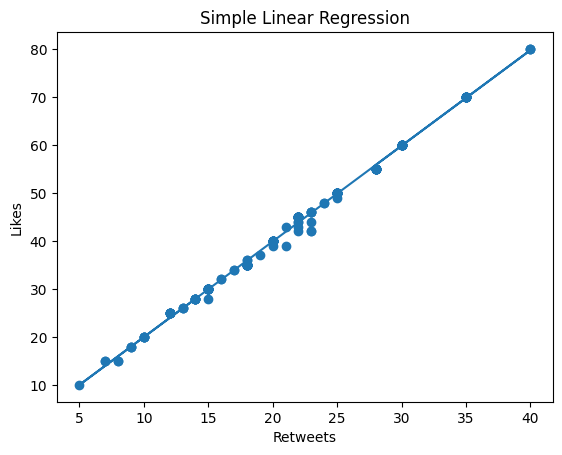

In [80]:
plt.scatter(X_test, Y_test)
plt.plot(X_test, Y_pred)

plt.xlabel("Retweets")
plt.ylabel("Likes")

plt.title("Simple Linear Regression")

plt.show()